# Solving the Time-Independent Schrödinger equation for a particle in a box

**A simple python tutorial on quantum mechanical simulations using QTCAD®**

## 1. Introduction

### 1.1 Goal

With this tutorial, we will discuss a bit further the [Schrödinger equation 🔗](https://en.wikipedia.org/wiki/Schr%C3%B6dinger_equation): its physical meaning, and how wavefunctions are affected by the **electrostatic (or potential) landscape** and the **boundary conditions** imposed on the system.

We will then solve the simple case of a **particle in a box** inside a rectangular domain, both analytically and using **QTCAD®**.  
The focus will be on a **qualitative understanding of the physics**, rather than on an in-depth discussion of numerical algorithms or theory.

This tutorial only assumes a basic familiarity with quantum mechanics and boundary conditions.  

<div class="alert alert-block alert-info" style="background: #F4F4F4">

Some freely available references on the physical concepts discussed in this tutorial are
- M. E. Tuckerman’s notes:
  - [Time-Independent Schrödinger Equation 🔗](https://chem.libretexts.org/Courses/Grinnell_College/CHM_364%3A_Physical_Chemistry_2_(Grinnell_College)/04%3A_Postulates_and_Principles_of_Quantum_Mechanics/4.04%3A_The_Time-Dependent_Schrodinger_Equation)
- OpenStax’s notes:
  - [Wavefunctions 🔗](https://phys.libretexts.org/Bookshelves/University_Physics/University_Physics_(OpenStax)/University_Physics_III_-_Optics_and_Modern_Physics_(OpenStax)/07%3A_Quantum_Mechanics/7.02%3A_Wavefunctions)
  - [Infinite Square Well 🔗](https://phys.libretexts.org/Courses/University_of_California_Davis/UCD%3A_Physics_9HC__Introduction_to_Waves_Physical_Optics_and_Quantum_Theory/7%3A_Quantum_Theory_in_Three_Dimensions/7.2%3A_3-Dimensional_Models)

</div>


### 1.2 Time-independent Schrödinger equation

The time-independent Schrödinger equation, introduced in the previous tutorial and also known as the stationary Schrödinger equation, is

$$
\displaystyle -\frac{\hbar^2}{2m} \nabla^2 \psi + V(\vec{r})\psi = E\psi.
$$

It is an [eigenvalue problem 🔗](https://phys.libretexts.org/Bookshelves/Nuclear_and_Particle_Physics/Introduction_to_Applied_Nuclear_Physics_(Cappellaro)/02%3A_Introduction_to_Quantum_Mechanics/2.04%3A_Energy_Eigenvalue_Problem) where
- $\psi$ is an eigenfunction, one of many possible solutions of the system. Physically, the absolute square of $|\psi^2|$, represents the probability density of finding the particle at a given point in space.- $ E $ is the associated eigenvalue, which is known as the **eigenenergy** in our context.

### 1.3 Confinement potential and boundary conditions

To find the stationary eigenstates and eigenenergies, we need two quantities:
1. The mass of the particle, $m$ and
2. The confinement potential $V(\vec{r})$ (for the electron in this case).

Therefore, for any problem we want to solve in QTCAD®, we must specify:
1. The material, which determines the relevant parameters for the simulation (e.g., the effective mass within the [effective-mass theory](https://en.wikipedia.org/wiki/Effective_mass_(solid-state_physics))).
2. The confinement potential, which can either be obtained from the electrostatic potential (as discussed in last week’s material) or it can be manually defined.

<div class="alert alert-block alert-info">

**Note**

In a typical QTCAD® simulation, we first solve the Poisson equation to obtain the electrostatic potential $\varphi(\vec{r})$. We then compute the confinement potential using 

$$
\displaystyle V(\vec{r}) = q (\varphi(\vec{r})-\varphi_F) - \chi,
$$

where for electrons $q = -e$, $\varphi_F$ is the reference potential that defines the potential gauge, and $\chi$ is the electron affinity of the material at that position. This represents the most commonly used workflow.

</div>

In this tutorial (first part of this second week), we artificially set the confinement potential to demonstrate how the Schrödinger solver works.

In the next tutorial (second part of this second week), you will see a more realistic example and a typical QTCAD® workflow, where the potential is first obtained from the Poisson equation and then used as an input to the Schrödinger equation.

### 1.4 Boundary conditions

Most boundary conditions in QTCAD® are defined for the **Poisson equation**, so common types like Dirichlet conditions affect wavefunctions indirectly via the electrostatic potential.  

For the **Schrödinger solver**, two boundary conditions are physically meaningful:

##### 3.1.1. Perfect insulator
- The wavefunction is set to zero at the boundary, which corresponds to a Dirichlet boundary condition  
- Physical meaning: the wavefunction cannot penetrate the barrier.
- Cases where it is common to use it: particle-in-a-box, oxide regions, or any region where penetration is neglected or forbidden.

##### 3.1.2. Natural boundary (zero normal flux)
- Ensures that **no probability current flows across the boundary**.  
- In QTCAD®, this boundary condition is applied automatically to any boundary that does not have an explicitly assigned condition. This behavior is similar to how QTCAD® handles the Poisson equation, where unspecified boundaries are treated in the same default way.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

For a more detailed explanation of these boundaries, please visit our documentation: [QTCAD®: Theory – Finite elements – 3. Schrödinger solvers: Boundary conditions 🔗](https://docs.nanoacademic.com/qtcad/theory_spin_fem/schrodinger/#boundary-conditions).

</div>

## 2. Analytical calculation of the wavefunction and eigenenergy for a particle in a 3D infinite well

In this tutorial, we consider a cubic domain of side length $a = 10~\text{nm}$ containing a smaller cube of side length $b = 1~\text{nm}$ at its centre. Both cubes are empty (vacuum), and the confinement potential $V(\vec{r})$ is:

- **Zero inside the small cube**, $V=0$,
- **Effectively infinite outside**, $V\to\infty$, preventing the wavefunction from leaving the small cube.

Theoretically, the infinite potential assumption allows for an analytical solution for the wavefunction and eigenenergies. However, in **numerical simulations**, this infinite assumption cannot be applied directly.

In QTCAD®, the insulator boundary condition is applied at the walls of the small cube. This forces the solver to find eigenfunctions that vanish at the boundaries, effectively modeling an infinite potential well. The same principle applies analytically

Alternatively, one could use a **very high but finite potential** to approximate the infinite well. This would give a close numerical result, but it does not exactly match the analytical solution.

<div><img src="figures/pib.png" width="500px"/></div>

Our **goal** is to determine the eigenenergy and eigenfunctions inside the smaller central box.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

This problem is adapted from Problem 4.2 of Griffiths, D. J. & Schroeter, D. F. [‘Introduction to quantum mechanics’ 🔗](https://openlibrary.org/books/OL28283255M/Introduction_to_Quantum_Mechanics). (Cambridge University Press, 2018). 978-1-107-18963-8, p. 132.

</div>


### 2.1 Geometry

In this problem, the spatial variables are constrained to values inside the two boxes.
The origin of the system of coordinates is at a bottom corner of the smaller box.
Also, both boxes are centred at $(x,y,z)=(b/2,b/2,b/2)$, the centre of the smaller box.

We can thus define the cubic domains associated with the first largest box,

$0<x<a, \hspace{2em} 0<y<a \hspace{2em}\text{and}\hspace{2em} 0<z<a$,

and with the second smaller cube,

$0<x<b, \hspace{2em} 0<y<b \hspace{2em}\text{and}\hspace{2em} 0<z<b$.


### 2.2 Analytical solution

For a 3D infinite potential well, the Schrödinger equation can be solved analytically using [separation of variables 🔗](https://phys.libretexts.org/Courses/University_of_California_Davis/UCD%3A_Physics_9D__Modern_Physics/9%3A_Quantum_Theory_in_Three_Dimensions/9.1%3A_Schr%C3%B6dinger's_Equation_in_3-Dimensions#section_3).
Because the potential is separable in the three spatial directions, the total wavefunction can be written as

$
\displaystyle 
\psi(\vec{r}) = \psi_x(x)\psi_y(y)\psi_z(z)
$

The normalized stationary states are

$
\displaystyle
\psi_{n_x n_y n_z}(x,y,z) =
\sqrt{\frac{8}{b^3}}
\sin\!\left(\frac{n_x \pi x}{b}\right)
\sin\!\left(\frac{n_y \pi y}{b}\right)
\sin\!\left(\frac{n_z \pi z}{b}\right),
$

with the corresponding eigenenergies being

$
\displaystyle
E_{n_x n_y n_z} =
\left(
\frac{n_x^2 + n_y^2 + n_z^2}{b^2}
\right)
\frac{h^2}{8m},
$

where $n_x, n_y, n_z = 1,2,3,\dots$.

#### 2.2.1 Ground State

The ground state corresponds to the state with the lowest allowed quantum number $ n_x, n_y, n_z = 1 $, which yield the **minimum possible energy**.

By replacing this in the previous equations, we find that the ground-state eigenfunction is

$\displaystyle
\psi_{1 1 1}(x,y,z) =
\sqrt{\frac{8}{b^3}}
\sin\!\left(\frac{\pi x}{b}\right)
\sin\!\left(\frac{\pi y}{b}\right)
\sin\!\left(\frac{\pi z}{b}\right),
$

and its eigenenergy is

$\displaystyle
E_{1 1 1} = \frac{3h^2}{8mb^2} = \frac{3(6.62\times 10^{-34})^2}{8(9.10\times 10^{-31}) (10^{-9})^2} = 1.81\times 10^{-19} \text{J} = 1.13 \text{eV}.
$

#### 2.2.2 Degeneracy

Due to the symmetry of the problem, different combinations of quantum numbers can lead to different eigenfunctions with the same energy.

For example, the states with quantum numbers
- $(n_x, n_y, n_z) = (2,1,1)$,
- $(n_x, n_y, n_z) = (1,2,1)$ and
- $(n_x, n_y, n_z) = (1,1,2)$

all have the same eigenenergy.

$\displaystyle
E_{2 1 1} = E_{1 2 1} = E_{1 1 2} = \frac{6h^2}{8mb^2} =  3.62\times 10^{-19} \text{J} = 2.26 \text{eV}.
$

Therefore:

- We say that the first excited level is **threefold degenerate**;
- Higher energy levels continue to show degeneracy patterns depending on combinations of $n_x, n_y, n_z$.

This degeneracy arises purely from the geometric **symmetry** of the cubic well.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

**Note**

For more information on degenerate states, see:
- On the context of a quantum particle in a box: T. Weideman’s notes [‘3-Dimensional Models: Degeneracy’ 🔗](https://phys.libretexts.org/Courses/University_of_California_Davis/UCD%3A_Physics_9HC__Introduction_to_Waves_Physical_Optics_and_Quantum_Theory/7%3A_Quantum_Theory_in_Three_Dimensions/7.2%3A_3-Dimensional_Models#section_3)
- General discussion: Wikipedia’s entry [‘Degenerate energy levels 🔗’](https://en.wikipedia.org/wiki/Degenerate_energy_levels)

</div>

## 3. Numerical simulation of the potential in a grounded box with a biased lid using QTCAD®

Having shown the analytical solution to the problem of a particle in a box, let us solve it numerically using QTCAD®.

Building on last week’s discussion, a typical QTCAD® simulation workflow includes:

1. **Device definition and meshing**  
2. **Simulation setup and execution**  
3. **Post-processing and analysis**

For more details, see [Getting Started: Workflow for QTCAD Simulations 🔗](https://docs.nanoacademic.com/qtcad/getting_started/workflow/).

### 3.1 Modelling the Device and Generating the Mesh with QTCAD®

Every QTCAD® simulation requires a device geometry, which can be either imported or created directly in QTCAD®.  
For finite-element simulations, a **mesh** must also be generated to form the geometry.

As in the previous tutorial, let us use QTCAD® [Builder 🔗](https://docs.nanoacademic.com/qtcad/builder/), a tool to create device geometries and generate meshes efficiently.

In our example, we simulate a box-within-a-box with the following parameters:

- Outer box: side length $a = 10~\text{nm}$  
- Inner box: side length $b = 1~\text{nm}$  

This is slightly more complex than the simple geometries discussed last week. Nevertheless, we can still use QTCAD® Builder to construct it.

<div class="alert alert-block alert-info" style="background: #F4F4F4">
    
QTCAD® Builder can handle much more complex geometries and meshes.  
More elaborate device designs will be explored in later sessions.

</div>

#### 3.1.1. Design

First, let us import the necessary modules and packages from QTCAD®, including Builder.

In [1]:
# Imports.
from qtcad.builder import Builder
from qtcad.builder import Mask, Polygon, MeshAlgorithm3D
from pathlib import Path

# Set up directories.
script_dir = Path("__file__").parent
mesh_dir = script_dir / "meshes"
output_dir = script_dir / "output"
mesh_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)
# Set up paths.
mesh_filepath = mesh_dir / "box_s.msh"

### 3.2 Creating 3D objects and using overlay mode in QTCAD® Builder

Building on last week’s content, we again define a box and add it to the ‘mask’⁽¹⁾, then extrude it to create a 3D object (the ‘device’).  
All the same steps as last week — `add_mask`, `use_shape`, `set_mesh_size`, `extrude`, and `view` — are still required.

#### 3.2.1 Overlay mode
QTCAD® Builder allows adding **multiple 2D shapes to the same mask** and combining them in 3D using [`overlay_mode` 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.builder/#qtcad.builder.Builder.overlay_mode).  

- **Functionality:** When two shapes intersect, Builder automatically detects the overlapping region and assigns it a new name, different from the names of the individual overlapping regions.  
- **Example:** If one shape is named `'box'` and another `'cube'`, the intersection is automatically named `'box.cube'`.

  <div><img src="figures/overlay.svg" width="500px"/></div>

  Additionally, all surfaces of the intersection region are named systematically, e.g., `'box.cube_top'`, `'box.cube_bottom'`, `'box.cube_side'`.  
- **API reference:** [QTCAD® Builder: overlay_mode 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.builder/)


This feature allows creating more complex devices by combining shapes directly on the mask, which was not covered last week.

<div class="alert alert-block alert-info">

**Note**

When you run the next cell, a new window will pop up with the device geometry displayed in Gmsh.
You can freely pan, rotate and zoom.

</div>

---

<small>
   
(1) The term ‘mask’ comes from the photolithography process used in semiconductor device fabrication.

</small>

In [2]:
# Define a simple box of side length `a` and `b`.
# The units of `a` will be defined later.
a = 10
b = 1
box = Polygon.box(width=a, height=a, name="box").centered()
cube = Polygon.box(width=b, height=b, name="cube").centered()

# Specify the characteristic length for meshing.
# This parameter determines the size of the mesh elements.
# Here we define two characteristic length to vary the mesh size
# inside the smaller box
char_len_a = 0.5
char_len_b = 0.03  # A finer mesh inside the well.

# Create a mask.
mask = Mask("my_mask")
mask.add_shape(box)
mask.add_shape(cube)

# Create the 3D device by adding and extruding.
builder = (
    Builder()
    # Add the mask and extrude the box.
    .add_mask(mask)
    .use_shape("box")
    .set_mesh_size(char_len_a)
    .extrude(a)
    # extruding the cube
    .use_shape("cube")
    .overlay_mode()  # Overlay mode for the intersections.
    .set_z(((a / 2) - (b / 2)))
    .set_mesh_size(char_len_b)
    .extrude(b)
    # View the final 3D model.
    .view(
        volume_labels=True,
        surfaces=True,
        angles=(-45, 0, 45),
        save=str(output_dir / "unrotated_model.svg"),
        font_size=20,
        zoom=0.7,
    )
)


|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   

                                 Version 2.1.3                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   

      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      

                        For documentation, please visit:                        
                      https:/

[10:11:00] INFO     Extruding shape 0 from mask 'my_mask' with name 'box' by 10 at z=0              ]8;id=157404;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=67856;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1359\1359]8;;\

[10:11:02] INFO     Creating new physical group with name 'box_bottom'                              ]8;id=697668;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=153374;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1254\1254]8;;\

           INFO     Creating new physical group with name 'box_side'                                ]8;id=943639;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=178572;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1254\1254]8;;\

           INFO     Creating new physical group with name 'box_top'                                 ]8;id=511878;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=230682;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1254\1254]8;;\

...

           INFO     Creating new physical group with name 'box.cube'                                ]8;id=377031;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=936840;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1254\1254]8;;\

           INFO     Creating new physical group with name 'box.cube_top'                            ]8;id=568606;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=377216;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1254\1254]8;;\

           INFO     Setting z-coordinate to 5.5                                                      ]8;id=166619;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=19203;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#418\418]8;;\

[10:11:07] INFO     Saving C:\Proyecto_QTCAD\output\unrotated_model.svg                              ]8;id=463814;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=170991;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#885\885]8;;\



Waiting for Gmsh viewer to be closed...


#### 3.2.2 Mesh

Now, let us generate the mesh from the geometry of the device.
When creating a device using QTCAD® Builder, we only need to call the method `mesh` with the appropriate parameters.

For more information on this method, please refer to its documentation: https://docs.nanoacademic.com/qtcad/API_reference/qtcad.builder/#qtcad.builder.Builder.view.

In [3]:
# Generate the mesh.
builder.mesh(3, algorithm3d=MeshAlgorithm3D.Delaunay, show_gmsh_output=True).write(
    mesh_filepath
)

[10:11:43] INFO     Preparing to mesh                                                                ]8;id=181432;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=221342;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#663\663]8;;\

           INFO     Detecting appropriate random factor                                             ]8;id=94196;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=654904;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1954\1954]8;;\

[10:11:44] INFO     Increased random factor from 1e-09 to 1.251904371282254e-06                     ]8;id=383823;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=176743;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1967\1967]8;;\

[10:11:45] INFO     Random factor is now appropriate                                                ]8;id=686334;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=132921;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1972\1972]8;;\

           INFO     Meshing                                                                          ]8;id=875805;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=658656;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#675\675]8;;\

[10:12:22] INFO     Checking mesh conformity                                                        ]8;id=669361;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=304897;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#2003\2003]8;;\

           INFO     Writing C:\Users\aefra\AppData\Local\Temp\tmppl6hxk8v\mesh.msh                   ]8;id=122190;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=509316;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#730\730]8;;\

[10:12:31] INFO     Checking connectivity                                                           ]8;id=537019;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=465786;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#2023\2023]8;;\

nodes:   0%|          | 0/39459 [00:00<?, ?it/s]

           INFO     Writing C:\Proyecto_QTCAD\meshes\box_s.msh                                       ]8;id=386013;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=241422;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#730\730]8;;\

### 3.3 Numerical simulation workflow with QTCAD®

As explained in last week’s tutorial, once the device geometry and mesh are ready, we follow a standard workflow in QTCAD®.  

Although this was covered previously, we will repeat the same steps here for clarity:

- **3.3.1 Importing the mesh**
  - The mesh can be generated with QTCAD® Builder (as in this tutorial) or imported from an external source.
- **3.3.2 Setting up the device**
  - Associate different regions with specific materials and define the boundary conditions for the simulation.
- **3.3.3 Running the simulation**
  - Execute the solver to compute the desired quantities.
- **3.3.4 Analyzing the results**
  - Extract and analyze the simulation outputs using QTCAD® post-processing tools.

Next, we proceed by importing the necessary classes and modules from QTCAD® to carry out these steps.

In [4]:
# Import NumPy for numerical operations.
import numpy as np

# Import QTCAD®’s `Mesh` and `SubMesh` classes in 3D and `Device` and `SubDevice` classes for the device.
from qtcad.device.mesh3d import Mesh, SubMesh
from qtcad.device import Device, SubDevice

# Import QTCAD®’s libraries `materials` and `constants` needed to assign materials to the device’s regions.
from qtcad.device import materials as mt
from qtcad.device import constants as ct

# Import QTCAD®’s Schrödinger solver and the module that allows us to set its parameters.
from qtcad.device.schrodinger import Solver as SchrodingerSolver
from qtcad.device.schrodinger import SolverParams as SchrodingerSolverParams

# Import QTCAD®’s analysis class to visualize the simulation results.
from qtcad.device import analysis as an

# Import matplotlib to visualize the results.
from matplotlib import pyplot as plt

Also, let us specify the scaling factor to correctly assign the unit of length in our problem.

That is, let us define the units of `a` and `b`. Since they were given in nanometres, the factor should be $10^{-9}$.

In [5]:
scaling_factor = 1e-9

#### 3.3.1 Importing the mesh

Let us import the mesh generated with Builder above and visualize it with the method `show` (https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.show).

Loading mesh from file:
 meshes\box_s.msh
Done.
3D MESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      252549              
Triangular elements           23604               
Tetrahedral elements          228945              
Total number of nodes         39459               
Boundary physical names       box_bottom, box_side, box_top, box.cube_side, box.cube_bottom, box.cube_top, 
Region physical names         box, box.cube,                


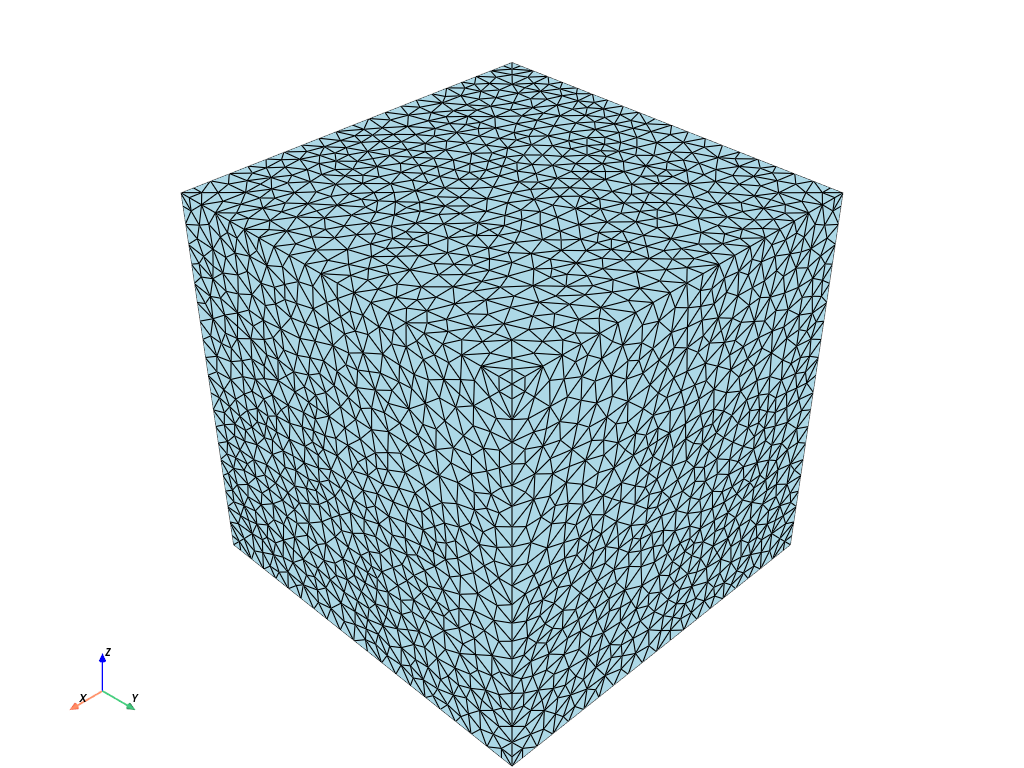

In [6]:
mesh = Mesh(scaling_factor=scaling_factor, filename=mesh_filepath)
mesh.show()

#### 3.3.2 Creating the device

Let us proceed to construct (instantiate, in proper terms) the `Device` object for the QTCAD® simulation.

First, we create the device from the mesh, specifying electrons as the charge carriers. Alternatively, one could choose holes as the carriers, depending on whether the device is dominated by electron or hole conduction.

In [7]:
dvc = Device(mesh, conf_carriers="e")

We then define the 3D regions, the outer and inner boxes, and assign their material properties with the [`new_region` method 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.new_region).

In this example, both boxes are ‘filled’ with vacuum.

In [8]:
dvc.new_region("box", material=mt.vacuum)
dvc.new_region("box.cube", material=mt.vacuum)

Next, let us set the boundary conditions. Since the surrounding surfaces of the inner box are insulators, we use the [`new_insulator` method 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.new_insulator).

In [9]:
dvc.new_insulator("box.cube_side")
dvc.new_insulator("box.cube_top")
dvc.new_insulator("box.cube_bottom")

Lastly, we set the electrostatic potential inside the inner box to zero with the [`set_V` method 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.set_V).

In [10]:
dvc.set_V(V=0.0, region="box.cube")

Explanation:

- `Device(mesh, conf_carriers="e")` creates the device object using the mesh, assuming electrons are the charge carriers.
- `new_region` defines volumetric regions of the device and associates them with a material (`mt.vacuum` in this case).
- `new_insulator` applies insulator boundary conditions to the surfaces, simulating an impenetrable barrier for the eigenfunctions.
- `set_V(V=0.0, region="box.cube")` sets the confinement potential inside the inner box to `0`, consistent with the particle-in-a-box setup.

After instantiating the device and defining its regions and boundary conditions, we can visualize the 3D geometry to verify the setup.

<div class="alert alert-block alert-info">

**Note**

When you run the next cell, a Jupyter widget will appear below it showing the device.
You can freely pan, rotate and zoom, as well as selectively show the different surfaces that make up the boxes.

</div>

In [11]:
# Visualize the device
dvc.show()

##### Using subdevices to optimize Schrödinger simulations

In many quantum simulations, the wavefunction is **localized** to a small region of the device.  
For example, in a particle-in-a-box or a quantum dot, the wavefunction is nearly zero outside the well.  

Solving the Schrödinger equation over the **entire device** is possible, but it is often **computationally expensive** and unnecessary.

To optimize resources (memory and computational run time), we can focus on a **subsection of the device** where the wavefunction is expected to be significant.

##### What is a subdevice?

A **`SubDevice`** is essentially a **‘child’ of the main device** that contains only a selected portion of the full device.  
It is always paired with a **`SubMesh`**, which defines the mesh over the selected region.  

The typical workflow is:

1. **Define the full mesh and device**  
2. **Define the `SubMesh`**  
  - You can select a subregion by:  
    - Using the **name tags** of the regions you want;
    - Defining a **box using two corner points**.
3. **Create the `SubDevice`**  
  - The Schrödinger solver can then be run **only on the `SubDevice`**, making the computation much more efficient.

As the full mesh and device were defined before, let us move to step 2 and define a submesh using the [`SubMesh` class 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.mesh3d/#qtcad.device.mesh3d.SubMesh).

We initialize it by passing the parent mesh and the label of the inner box and visualize it with the `show` method.

3D SUBMESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      186457              
Triangular elements           17268               
Tetrahedral elements          169189              
Total number of nodes         31455               
Boundary physical names       box.cube_side, box.cube_bottom, box.cube_top, 
Region physical names         box.cube,                     


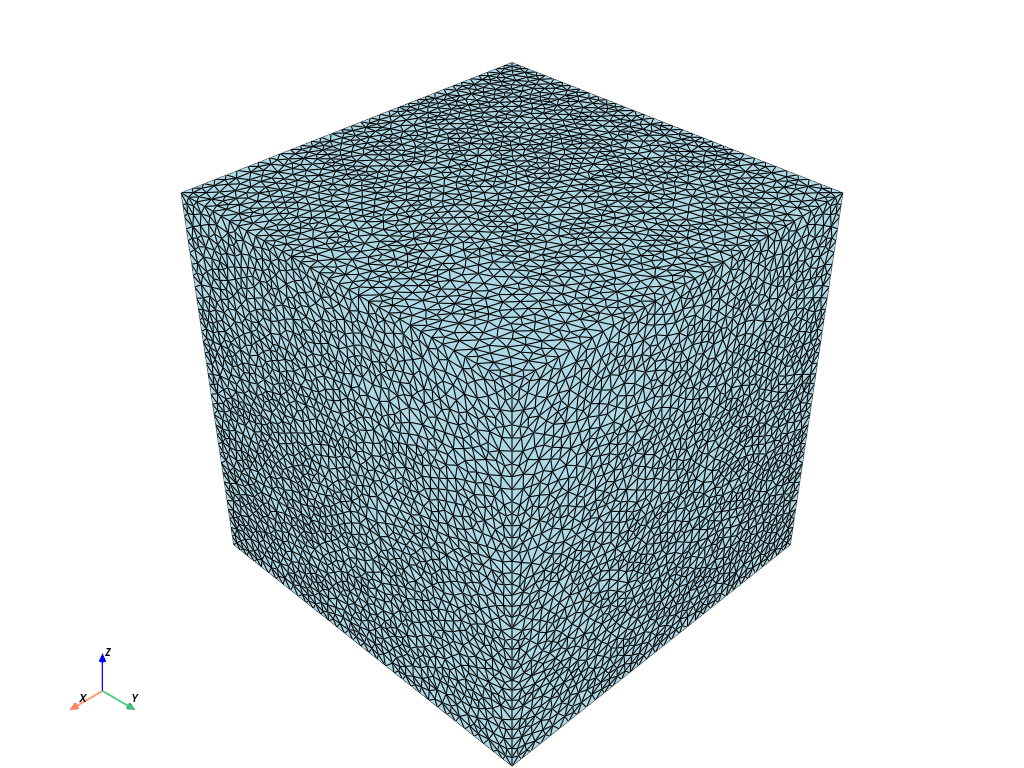

In [13]:
submesh = SubMesh(parent=mesh, nodes="box.cube")
submesh.show()  # Visualize the submesh

Next, in step 3, we create a subdevice by using the [`SubDevice` class 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.SubDevice).

We initialize it by specifying the parent `Device` object from which the subdevice will be built and the `SubMesh` object defined in the previous step.

In [14]:
subdvc = SubDevice(parent=dvc, submesh=submesh)

#### 3.3.3 Running the simulation

With the device (or subdevice) fully defined and the boundary conditions applied, we can now **set up the Schrödinger solver** and compute the wavefunctions and eigenenergies.

We start by initializing the object that will store the Schrödinger solver’s parameters and then customizing some of its settings.

In [15]:
# Initialize solver parameters.
params_schrod = SchrodingerSolverParams()

# Define solver parameters.
# - Number of eigenstates to compute.
params_schrod.num_states = 4
# - Tolerance for the solver.
params_schrod.tol = 1e-8

Explanation of the above parameters:
- `num_states` determines how many eigenenergies and eigenfunctions the solver will calculate.
- `tol` sets the tolerance for the convergence of the solution.

All possible parameters are described at https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.schrodinger/#qtcad.device.schrodinger.SolverParams.

Then, we can create (instantiate) the Schrödinger solver with the device and solver parameters defined in the previous steps.

In [16]:
s = SchrodingerSolver(subdvc, solver_params=params_schrod)

Lastly, we call the `solve` method to solve the Scrödinger equation.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

**Note on warnings**

Since we set the confinement potential to zero inside the box, any warnings about undefined potentials when solving the Schrödinger equation in this case can be safely ignored.

</div>

In [17]:
s.solve()

c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\device\core\schrodinger.py:333: UserWarning: The confinement potential is zero everywhere. Did you forget to set the confinement potential using, e.g., set_V_fom_phi?
  warn("The confinement potential is zero everywhere. "+                "Did you forget to set the confinement potential "+                "using, e.g., set_V_fom_phi?")


--------------------------------------------------------------------------------
Solving Schrödinger's equation for electrons.
--------------------------------------------------------------------------------
Schrodinger's equation solved in 4.376418100204319 s.


#### 3.3.4 Analyzing the results

After running the solver, the computed eigenenergies can be printed using the [`print_energies` method 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.print_energies)

In [18]:
subdvc.print_energies()

Energy levels (eV)
[1.13374938 2.27857510 2.27860586 2.27868330]


##### **Comparison with analytical predictions**

| Method | Ground state ($E_{1 1 1}$) |
|-|-|
| Analytical | 1.13 eV |
| Numerical | 1.134 eV |

| Method | First excited states ($E_{2 1 1} = E_{1 2 1} = E_{1 1 2}$) |
|-|-|
| Analytical | 2.26 eV (threefold degenerate) |
| Numerical | 2.279, 2.279, 2.279 eV |

**Observations:**
- The ground state matches the analytical value closely.
- The threefold degeneracy of the first excited states is accurately reproduced.
- The slight differences in the results come from the finite-element discretization. Nonetheless, the overall pattern and magnitudes are consistent with theory.

##### **Plotting the ground-state eigenfunction**

The eigenfunctions computed by the Schrödinger solver are stored in the attribute `subdvc.eigenfunctions` for a [`SubDevice` 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device) or, if using the full device, [`dvc.eigenfunctions` 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device).

In this array:

- The **first index** corresponds to the **mesh nodes**.  
- The **second index** corresponds to the **state number**:  
  - `0` → ground state  
  - `1` → first excited state  
  - and so on. 

##### **Slices**

As discussed last week, we can visualize the results of the simulation using [**2D slices** of the device 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.analysis/#qtcad.device.analysis.plot_slices).

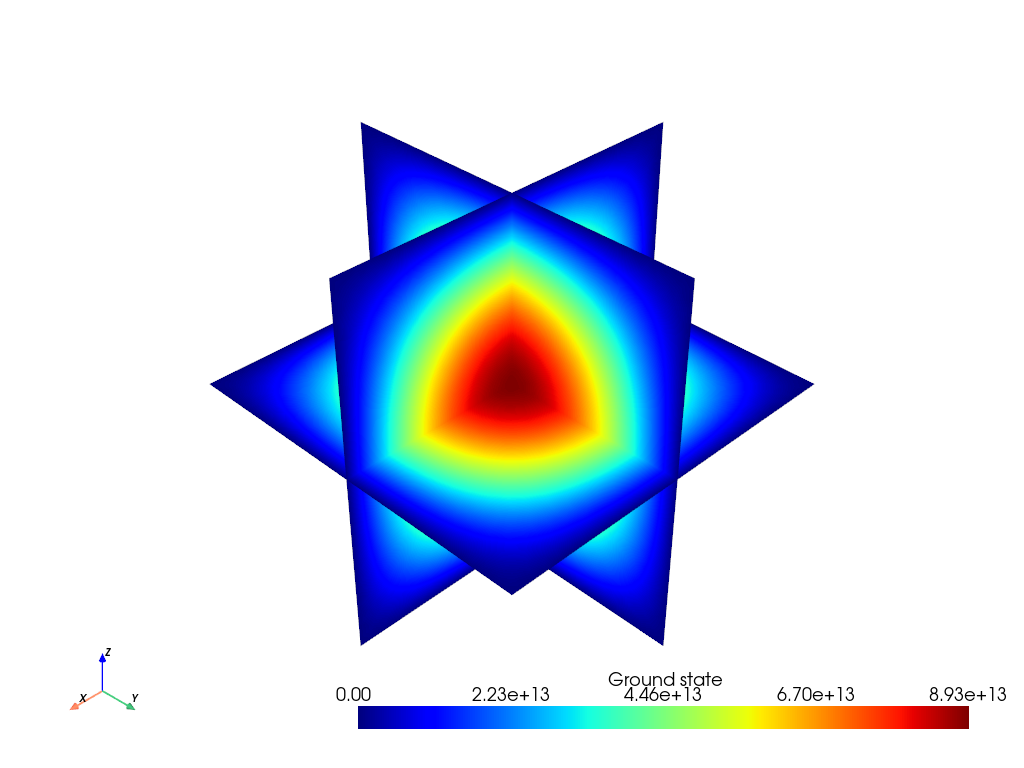

In [19]:
# Here, the first index of the eigenfunctions array represents the mesh nodes while the
# second index represents the order of statess (0 is ground, 1 is 1st excited, ...)
an.plot_slices(submesh, array=subdvc.eigenfunctions[:, 0], title="Ground state")

For the **ground state**, the analytical wavefunction is

$\displaystyle
\Psi_{111}(x,y,z) = A \, \sin\!\left(\frac{\pi x}{b}\right) 
                        \sin\!\left(\frac{\pi y}{b}\right) 
                        \sin\!\left(\frac{\pi z}{b}\right),
$

where $A$ is the **normalization constant**.

Also, the wavefunction consists of **sine waves in all three directions**, reflecting confinement along $x$, $y$, and $z$.  

This analytical form is consistent with the **numerical results** shown above, confirming that the QTCAD® solver accurately reproduces the expected ground-state wavefunction.


Similarly, we can visualize the **first three excited states** of the particle in the box using slices of their eigenfunctions:

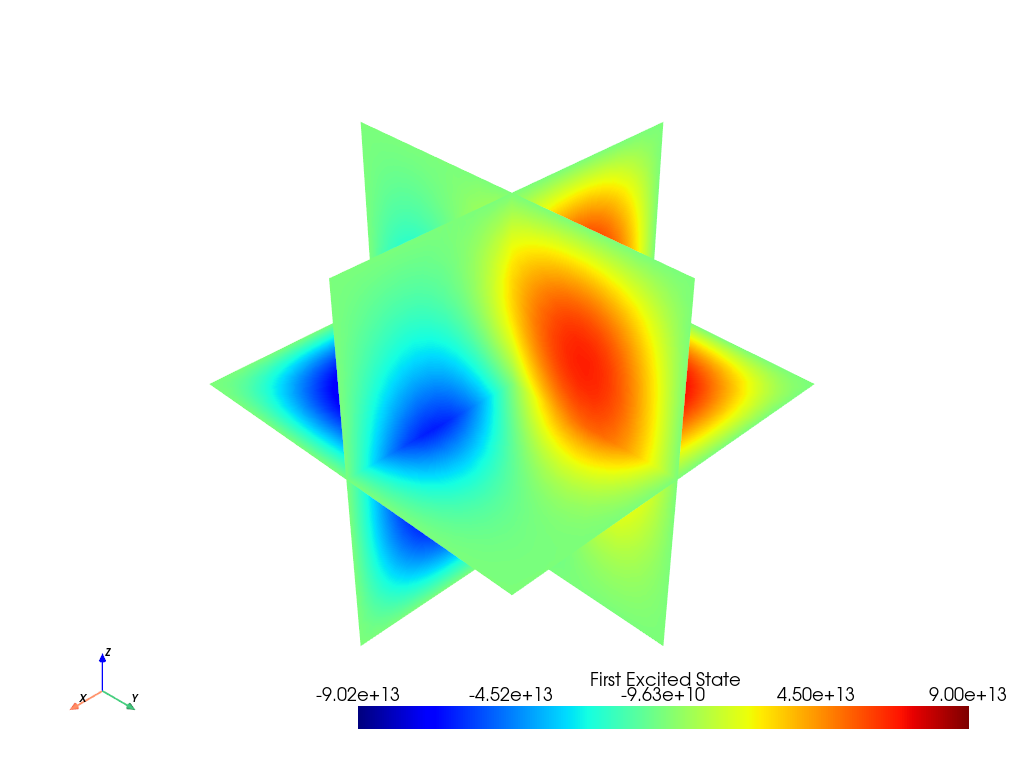

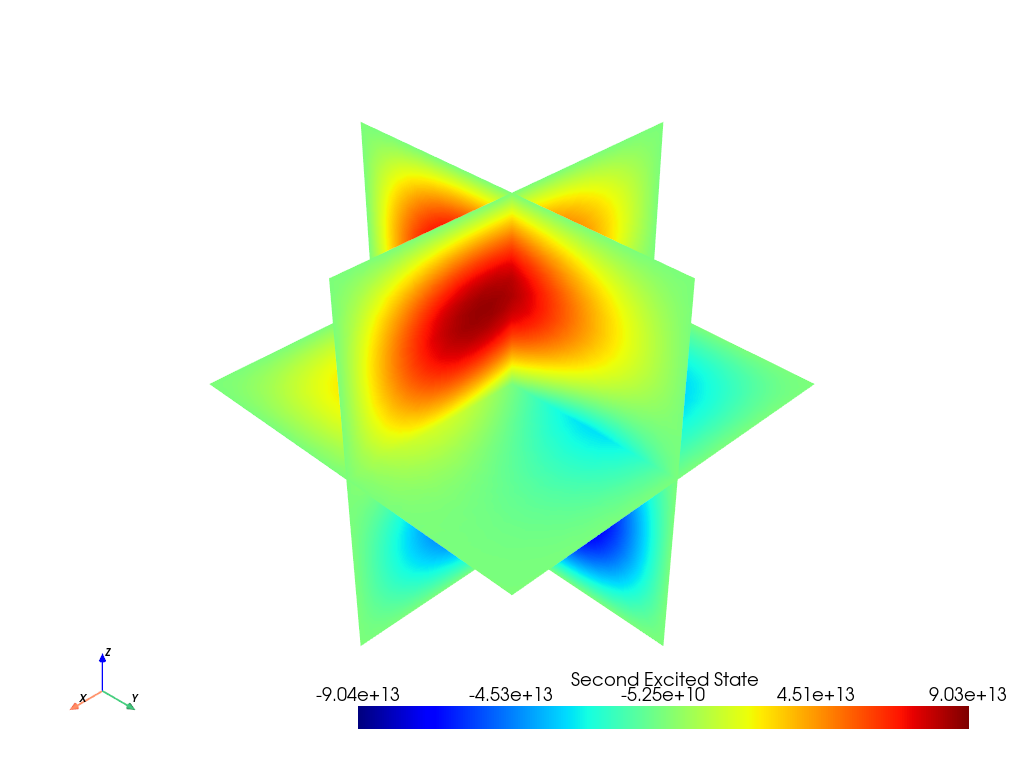

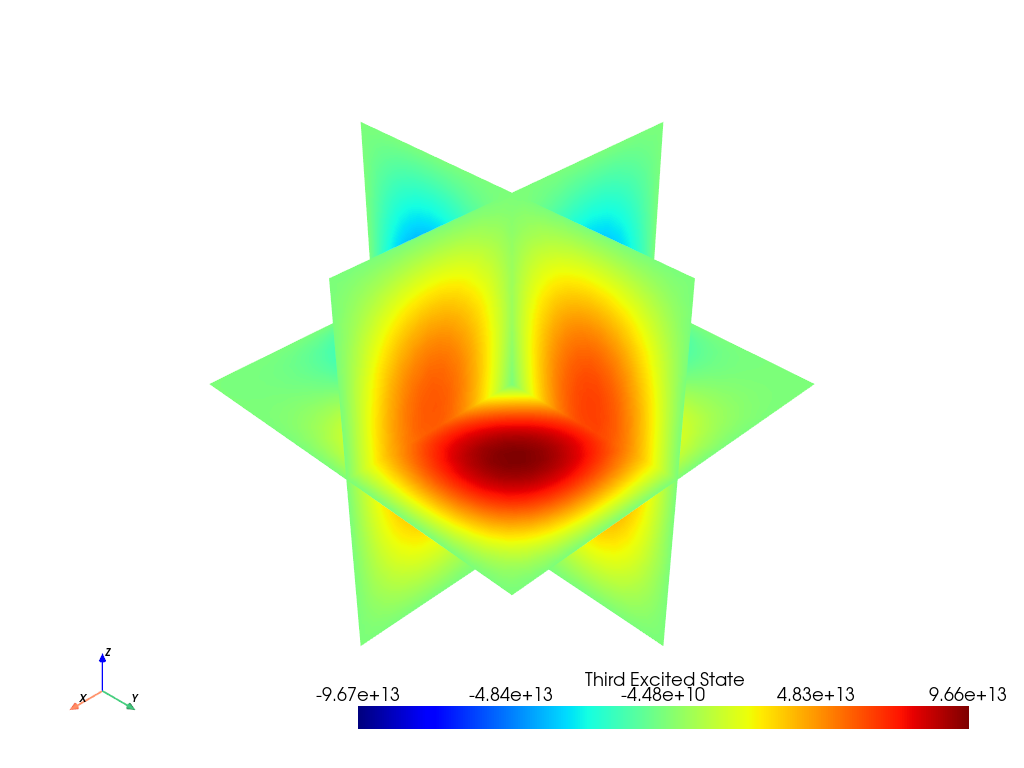

In [20]:
# First excited state.
an.plot_slices(submesh, array=subdvc.eigenfunctions[:, 1], title="First Excited State")

# Second excited state.
an.plot_slices(submesh, array=subdvc.eigenfunctions[:, 2], title="Second Excited State")

# Third excited state.
an.plot_slices(submesh, array=subdvc.eigenfunctions[:, 3], title="Third Excited State")

The three first excited states of a particle in a 3D cubic box ($b \times b \times b$) are degenerate and have **one quantum number equal to 2** and the others equal to 1. Their analytical wavefunctions are

$\displaystyle
\Psi_{211}(x,y,z) = A \, \sin\!\left(\frac{2 \pi x}{b}\right) 
                         \sin\!\left(\frac{\pi y}{b}\right) 
                         \sin\!\left(\frac{\pi z}{b}\right),
$

$\displaystyle
\Psi_{121}(x,y,z) = A \, \sin\!\left(\frac{\pi x}{b}\right) 
                         \sin\!\left(\frac{2 \pi y}{b}\right) 
                         \sin\!\left(\frac{\pi z}{b}\right),
$

and

$\displaystyle
\Psi_{112}(x,y,z) = A \, \sin\!\left(\frac{\pi x}{b}\right) 
                         \sin\!\left(\frac{\pi y}{b}\right) 
                         \sin\!\left(\frac{2 \pi z}{b}\right),
$

where $A$ is the **normalization constant**. 

Note that:
- The **eigenenergy** for all three states is the same:

  $\displaystyle
  E = \frac{6 h^2}{8 m b^2} \approx 2.26\ \text{eV}
  $

##### **Note on numerical results**

In the numerical simulation, the solver may return eigenfunctions that **do not exactly match these forms along x, y, z**. This is because the three states are **degenerate**, and any [**rotation or linear combination** 🔗](https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Quantum_Physics_(Ackland)/03%3A_Dealing_with_Degeneracy/3.06%3A_Wavefunction_Collapse_onto_degenerate_levels) of these functions is also a valid solution. The orientation of the eigenfunctions may therefore appear **rotated relative to the mesh axes**, but they still span the correct degenerate subspace.

##### **Optional exercise**

Consider the three degenerate numerical eigenfunctions from the `SubDevice`:

```python
psi1 = subdvc.eigenfunctions[:,1]
psi2 = subdvc.eigenfunctions[:,2]
psi3 = subdvc.eigenfunctions[:,3]
```

**Questions:**

- How can you compute the *inner products* between these three eigenfunctions? Compute them.
- What do the results tell you about their overlap and the orientation/rotation of the degenerate states relative to the mesh axes?

##### **Line cuts and additional slices**

Finally, similar to last week's tutorial, we can visualize the eigenfunctions using **linecuts** or **specific slices** through the subdevice:

- **Linecuts:** Plot the value of the eigenfunction along a chosen line (e.g., along $x$, $y$ or $z$) to inspect its variation in one dimension.  
- **Specific slices:** Plot a 2D slice of the eigenfunction at a fixed coordinate (e.g., $z = b/2$) to examine its spatial distribution in a plane.

##### **Line cuts**

Let us plot the line cuts of the first four states (ground state + 3 excited states).

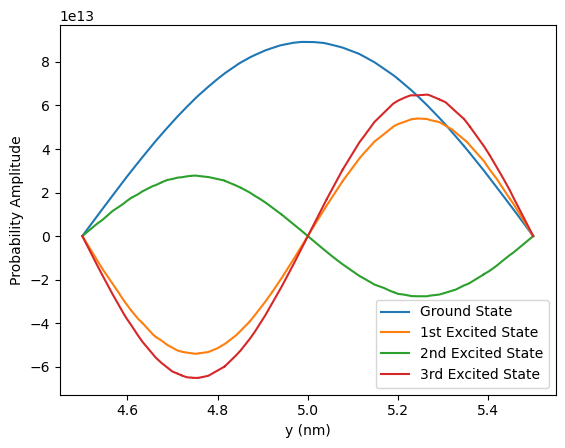

In [21]:
x_0, p0 = an.linecut(
    submesh,
    array=subdvc.eigenfunctions[:, 0],
    begin=(0, -5e-9, 5e-9),
    end=(0, 5e-9, 5e-9),
)
x_1, p1 = an.linecut(
    submesh,
    array=subdvc.eigenfunctions[:, 1],
    begin=(0, -5e-9, 5e-9),
    end=(0, 5e-9, 5e-9),
)
x_2, p2 = an.linecut(
    submesh,
    array=subdvc.eigenfunctions[:, 2],
    begin=(0, -5e-9, 5e-9),
    end=(0, 5e-9, 5e-9),
)
x_3, p3 = an.linecut(
    submesh,
    array=subdvc.eigenfunctions[:, 3],
    begin=(0, -5e-9, 5e-9),
    end=(0, 5e-9, 5e-9),
)

fig, ax = plt.subplots()
ax.plot(x_0 * 1e9, p0, label="Ground State")
ax.plot(x_1 * 1e9, p1, label="1st Excited State")
ax.plot(x_2 * 1e9, p2, label="2nd Excited State")
ax.plot(x_3 * 1e9, p3, label="3rd Excited State")

ax.set_xlabel("y (nm)")
ax.set_ylabel("Probability Amplitude")
ax.legend()
plt.show()

**Notes:**

- `x_i` is the position along the line and `p_i` is the wavefunction amplitude at those points.
- Multiplying `x_i` by `1e9` converts metres to nanometres for easier interpretation.
- This plot provides a 1D view of the spatial variation of each eigenfunction along the chosen line, complementing the 2D slices.
- It allows easy comparison of nodes, amplitude, and phase between the ground and excited states.

###### **Individual 2D slices**

Lastly, let us plot individual 2D projections of the ground state and first three excited states as intensity plots.

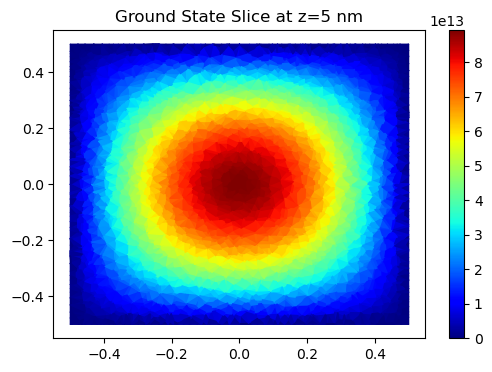

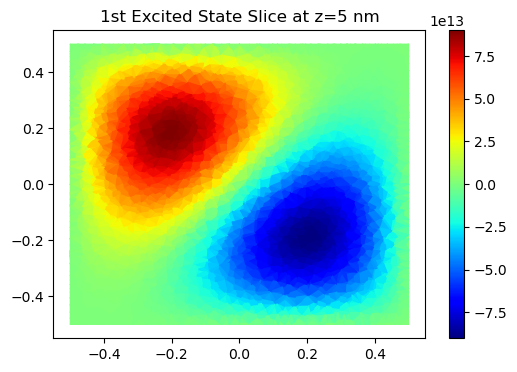

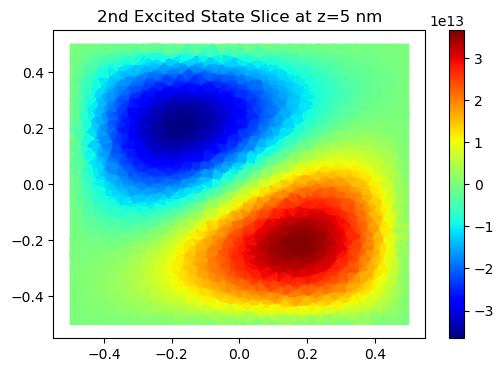

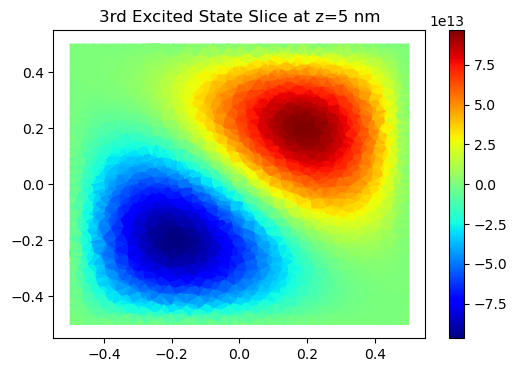

In [22]:
an.plot_slice(
    submesh,
    arr=subdvc.eigenfunctions[:, 0],
    normal=(0, 0, 1),
    origin=(0, 0, 5e-9),
    title="Ground State Slice at z=5 nm",
)
an.plot_slice(
    submesh,
    arr=subdvc.eigenfunctions[:, 1],
    normal=(0, 0, 1),
    origin=(0, 0, 5e-9),
    title="1st Excited State Slice at z=5 nm",
)
an.plot_slice(
    submesh,
    arr=subdvc.eigenfunctions[:, 2],
    normal=(0, 0, 1),
    origin=(0, 0, 5e-9),
    title="2nd Excited State Slice at z=5 nm",
)
an.plot_slice(
    submesh,
    arr=subdvc.eigenfunctions[:, 3],
    normal=(0, 0, 1),
    origin=(0, 0, 5e-9),
    title="3rd Excited State Slice at z=5 nm",
)

**Notes:**

- `normal=(0,0,1)` defines the slice perpendicular to the $z$-axis.
- `origin=(0,0,5e-9)` sets the position of the slice along $z$.
- This provides a 2D view of the eigenfunction amplitude across the $x$–$y$ plane at $z = 5$ nm.
- Slice plots complement linecuts by showing the spatial distribution of nodes and peaks in the plane, making it easier to see the differences between the ground and excited states.

## 4. Final considerations

In this tutorial, we considered a simple cubic box problem and demonstrated how to use QTCAD® to solve the **time-independent Schrödinger equation**. This example illustrates the core steps involved in many QTCAD® simulations:

- **Creating the geometry and mesh** using QTCAD® Builder.  
- **Defining the device** and its parameters, including materials assigned to each region and the boundary conditions for the Schrödinger equation.  
- **Visualizing the device** to verify that the boundary conditions and materials are correctly assigned.  
- **Instantiating and running the Schrödinger solver** in QTCAD®.  
- **Visualizing and analyzing the results**, comparing the numerical solution with the analytical solution where available.

As discussed last week, analytical solutions are not always readily available, and **numerical methods are a powerful tool** for simulating more complex devices, such as spin qubits. Furthermore, the **accuracy** of any finite-element method (including QTCAD®) depends on the **mesh density** and the **solver tolerance**.

<div class="alert alert-block alert-info">

**Next**

After this introductory tutorials on the usage of QTCAD® in the analysis of simple quantum system, from now on, we will focus on the simulation of semiconductor quantum devices. In the next tutorial, we will simulate a **single quantum dot in silicon**.

</div>

## 5. Optional exercises

We invite you to make a copy of this notebook file and modify it to explore a bit further the example of a particle in a box. Here are some prompts to guide you:

- Modify the geometry to a **rectangular box** and see how the eigenenergies and eigenfunctions change.
- Solve the problem with a **finite potential well** (i.e., outside the box, $V_0$ is set to a finite value$).